# XAI-project — Contraste empírico L1 vs L2

**Course:** INF-473 Explainable AI · UTFSM · Prof. Raquel Pezoa Rivera
**Authors:** Eduardo Morales · Octavia Jara · Benjamín Reyes

**Notebook:** `modeling/02_l1_vs_l2_experiment` — contrasta dos modelos XGBoost (L1 = área quemada, L2 = intensidad EWE) con Tree SHAP y faithfulness de Quantus. Escribe `eda/L1_vs_L2_Experiment_Report.html` y muestra cada figura inline.

> Requiere `data/processed/conaf_enriched_2012_2018.parquet`. Ver [`README.md`](../README.md).

In [1]:
%matplotlib inline
import json
import base64
import sys
from pathlib import Path
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import quantus
import quantus.helpers.utils as quantus_utils
import quantus.helpers.asserts as quantus_asserts
from IPython.display import display

# Monkey-patch Quantus to support XGBoost/tabular models
class TabularModelWrapper:
    """Adaptador mínimo que envuelve un modelo tabular para la API de Quantus.

    Quantus asume modelos tipo red neuronal; este wrapper expone la interfaz que
    espera (``predict``, ``shape_input``, ...) delegando en un clasificador
    sklearn/XGBoost.
    """

    def __init__(self, model):
        """Guarda el modelo envuelto.

        Args:
            model: Clasificador con método ``predict_proba`` (p. ej. XGBClassifier).
        """
        self.model = model

    def predict(self, x, **kwargs):
        """Devuelve las probabilidades de clase del modelo envuelto.

        Args:
            x: Matriz de características (n_muestras, n_features).
            **kwargs: Ignorados; presentes por compatibilidad con Quantus.

        Returns:
            Array de probabilidades por clase.
        """
        return self.model.predict_proba(x)

    def shape_input(self, x, *args, **kwargs):
        """Devuelve la entrada sin transformar (los datos tabulares ya tienen la forma correcta).

        Args:
            x: Matriz de características.
            *args: Ignorados.
            **kwargs: Ignorados.

        Returns:
            La misma matriz ``x``.
        """
        return x

    def get_model(self):
        """Devuelve el modelo subyacente.

        Returns:
            El clasificador envuelto.
        """
        return self.model

    def state_dict(self):
        """Devuelve un estado vacío (los modelos de árbol no exponen pesos).

        Returns:
            Diccionario vacío.
        """
        return {}

quantus_utils.get_wrapped_model = lambda model, **kwargs: TabularModelWrapper(model)

# Fix Quantus bug for 2D tabular data in assert_value_smaller_than_input_size
def fixed_assert(x, value, value_name):
    """Valida que ``value`` sea menor que el tamaño de entrada, también para datos 2D.

    Reemplaza el assert de Quantus, que asume tensores de imagen (>2D) y falla con
    matrices tabulares de forma (n_muestras, n_features).

    Args:
        x: Array de entrada; tabular (2D) o de mayor dimensión.
        value: Valor a validar (p. ej. número de features por paso).
        value_name: Nombre del parámetro, para el mensaje de error.

    Raises:
        ValueError: Si ``value`` no es menor que el tamaño de entrada.
    """
    if len(x.shape) > 2:
        if value >= np.prod(x.shape[2:]):
            raise ValueError(f"'{value_name}' must be smaller than input size.")
    elif len(x.shape) == 2:
        if value >= x.shape[1]:
            raise ValueError(f"'{value_name}' must be smaller than input size.")

quantus_asserts.assert_value_smaller_than_input_size = fixed_assert

def fixed_assert_features(features_in_step, input_shape):
    """Valida la divisibilidad de features por paso, omitiendo el chequeo en datos tabulares.

    Args:
        features_in_step: Número de features perturbadas por paso.
        input_shape: Forma de la entrada; vacía para datos tabulares.

    Raises:
        AssertionError: Si el número de features no es divisible por ``features_in_step``
            (solo cuando ``input_shape`` no es tabular).
    """
    if len(input_shape) == 0: # Tabular
        return # Skip check or refine
    assert np.prod(input_shape) % features_in_step == 0

quantus_asserts.assert_features_in_step = fixed_assert_features

from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import BASE_DIR, DATA_PROCESSED  # noqa: E402
from src.modeling_features import (  # noqa: E402
    FEATURE_COLS,
    MEGAFIRE_HA_THRESHOLD,
    N_SPLITS,
    RANDOM_STATE,
    STUDY_REGIONS,
    XGB_PARAMS,
)

HTML_OUT = BASE_DIR / "eda" / "L1_vs_L2_Experiment_Report.html"

def image_to_base64(fig):
    """Serializa una figura de matplotlib a PNG base64 y la muestra inline.

    Args:
        fig: Figura de matplotlib a renderizar. Se muestra inline y se cierra
            tras serializarla.

    Returns:
        El PNG de la figura como cadena base64 (para incrustar en HTML).
    """
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode("utf-8")
    display(fig)
    plt.close(fig)
    return b64

## 1. Carga de datos y preparación de features/labels (2012–2018, 4 regiones de estudio)

In [2]:
print("Loading data 2012-2018...")
df = pd.read_parquet(DATA_PROCESSED / "conaf_enriched_2012_2018.parquet")
df = df[df["region"].astype(str).isin(STUDY_REGIONS)].copy()

# Process features
ts = pd.to_datetime(df["fecha_hora_inicio"], errors="coerce")
df["month"] = ts.dt.month
df["hour"] = ts.dt.hour
df["day_of_year"] = ts.dt.dayofyear

# Copia local: FEATURE_COLS es la fuente única importada; no debe mutarse.
feature_cols = list(FEATURE_COLS)

# Categorical encoding
for c in ["region", "provincia", "comuna"]:
    df[c] = pd.Categorical(df[c]).codes

# Ensure all feature columns are numeric
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop columns that are 100% NaN
all_nan_cols = [c for c in feature_cols if df[c].isna().all()]
if all_nan_cols:
    print(f"Dropping all-NaN columns: {all_nan_cols}")
    for c in all_nan_cols:
        feature_cols.remove(c)

# Drop Nans in target or remaining features
df = df.dropna(subset=["superficie_quemada_total_ha", "label_l2"] + feature_cols).copy()

# Label definition
df["label_l1"] = (df["superficie_quemada_total_ha"] >= MEGAFIRE_HA_THRESHOLD).astype(int)
y_l1 = df["label_l1"]
y_l2 = df["label_l2"].astype(int)
X = df[feature_cols]

print(f"Data ready. Total rows: {len(df)}")
print(f"L1 Positives: {y_l1.sum()} | L2 Positives: {y_l2.sum()}")

Loading data 2012-2018...
Data ready. Total rows: 30511
L1 Positives: 76 | L2 Positives: 11


## 2. Métricas honestas out-of-fold (CV estratificada)

In [3]:
# Class weights for training
spw_l1 = (len(y_l1) - y_l1.sum()) / max(y_l1.sum(), 1)
spw_l2 = (len(y_l2) - y_l2.sum()) / max(y_l2.sum(), 1)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Honest metrics: out-of-fold probabilities (no train==test leakage)
print("Cross-validating Model L1 (OOF)...")
oof_l1 = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw_l1)
p_l1 = cross_val_predict(oof_l1, X, y_l1, cv=skf, method="predict_proba")[:, 1]

print("Cross-validating Model L2 (OOF)...")
oof_l2 = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw_l2)
p_l2 = cross_val_predict(oof_l2, X, y_l2, cv=skf, method="predict_proba")[:, 1]

roc_l1, pr_l1 = roc_auc_score(y_l1, p_l1), average_precision_score(y_l1, p_l1)
roc_l2, pr_l2 = roc_auc_score(y_l2, p_l2), average_precision_score(y_l2, p_l2)
print(f"L1  ROC-AUC={roc_l1:.4f}  PR-AUC={pr_l1:.4f}")
print(f"L2  ROC-AUC={roc_l2:.4f}  PR-AUC={pr_l2:.4f}")

Cross-validating Model L1 (OOF)...


Cross-validating Model L2 (OOF)...


L1  ROC-AUC=0.9110  PR-AUC=0.1107
L2  ROC-AUC=0.7696  PR-AUC=0.0046


## 3. Modelos finales sobre toda la data + Tree SHAP

In [4]:
# Final full-data models, used only for SHAP/Quantus explanations
print("Training final full-data Model L1...")
model_l1 = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw_l1)
model_l1.fit(X, y_l1)

print("Training final full-data Model L2...")
model_l2 = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw_l2)
model_l2.fit(X, y_l2)

print("Explaining with SHAP...")
# Using a subset for faster global shap if needed, but here we use all for precision
exp_l1 = shap.TreeExplainer(model_l1)
sv_l1 = exp_l1(X)

exp_l2 = shap.TreeExplainer(model_l2)
sv_l2 = exp_l2(X)

Training final full-data Model L1...


Training final full-data Model L2...


Explaining with SHAP...


## 4. Faithfulness con Quantus

In [5]:
print("Evaluating Faithfulness with Quantus...")
# Using a subset of the dataset for Quantus if it's too slow, but 17k rows is manageable
# We'll use 500 random samples to keep it fast while being representative
rng = np.random.default_rng(RANDOM_STATE)
eval_idx = rng.choice(len(X), size=min(500, len(X)), replace=False)
x_np = X.iloc[eval_idx].values
y_l1_np = y_l1.iloc[eval_idx].values
y_l2_np = y_l2.iloc[eval_idx].values
a_l1_np = sv_l1.values[eval_idx]
a_l2_np = sv_l2.values[eval_idx]

# 1. Faithfulness Correlation (Bhatt et al., 2020)
fc_metric = quantus.FaithfulnessCorrelation(
    nr_runs=50, subset_size=int(X.shape[1] * 0.1) or 1,
    perturb_baseline="mean", abs=True, disable_warnings=True
)

# 2. Faithfulness Estimate (Alvarez-Melis & Jaakkola, 2018)
fe_metric = quantus.FaithfulnessEstimate(
    features_in_step=2,
    perturb_baseline="mean", disable_warnings=True
)

print("  Calculating L1 Faithfulness...")
fc_l1 = fc_metric(model=model_l1, x_batch=x_np, y_batch=y_l1_np, a_batch=a_l1_np)
fe_l1 = fe_metric(model=model_l1, x_batch=x_np, y_batch=y_l1_np, a_batch=a_l1_np)

print("  Calculating L2 Faithfulness...")
fc_l2 = fc_metric(model=model_l2, x_batch=x_np, y_batch=y_l2_np, a_batch=a_l2_np)
fe_l2 = fe_metric(model=model_l2, x_batch=x_np, y_batch=y_l2_np, a_batch=a_l2_np)

# Metrics Summary for HTML
q_metrics = {
    "l1_fc": np.mean(fc_l1), "l1_fe": np.mean(fe_l1),
    "l2_fc": np.mean(fc_l2), "l2_fe": np.mean(fe_l2)
}
print(q_metrics)

Evaluating Faithfulness with Quantus...
  Calculating L1 Faithfulness...


  Calculating L2 Faithfulness...


{'l1_fc': np.float64(0.41982994675682855), 'l1_fe': np.float64(-0.6232285373504274), 'l2_fc': np.float64(0.36518647562759), 'l2_fe': np.float64(-0.5664897999018431)}


## 5. SHAP global (beeswarm) — se muestra inline y se incrusta en el reporte

Generating Global Plots...


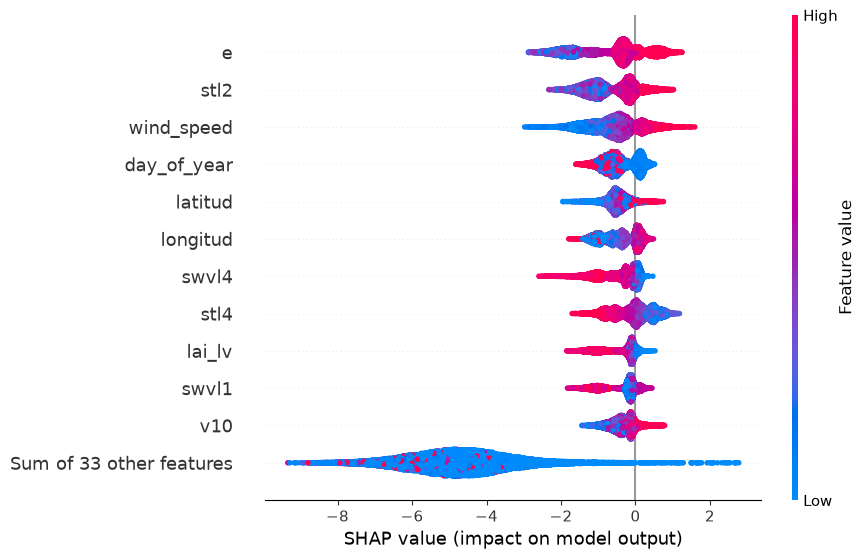

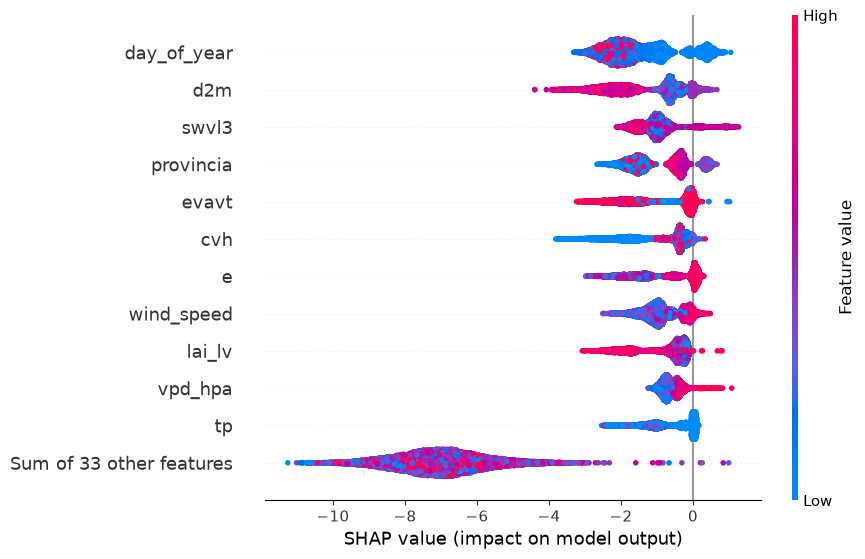

In [6]:
# Global Plots
print("Generating Global Plots...")
shap.plots.beeswarm(sv_l1, max_display=12, show=False)
b64_global_l1 = image_to_base64(plt.gcf())

shap.plots.beeswarm(sv_l2, max_display=12, show=False)
b64_global_l2 = image_to_base64(plt.gcf())

## 6. Selección de 4 instancias representativas

In [7]:
# Select Instances
# idx 1 & 2: Pure L1
pure_l1_df = df[(df["label_l1"] == 1) & (df["label_l2"] == 0)]
idx_pure_l1_1 = pure_l1_df["superficie_quemada_total_ha"].idxmax()
idx_pure_l1_2 = pure_l1_df.sort_values("superficie_quemada_total_ha", ascending=False).index[1]

# idx 3: Pure L2
pure_l2_df = df[(df["label_l1"] == 0) & (df["label_l2"] == 1)]
idx_pure_l2 = pure_l2_df["modis_frp_max_mw"].idxmax()

# idx 4: Both
both_df = df[(df["label_l1"] == 1) & (df["label_l2"] == 1)]
idx_both = both_df["modis_frp_max_mw"].idxmax()

instances = {
    "Instance 1: L1=1, L2=0 (Pure L1, Highest Area)": idx_pure_l1_1,
    "Instance 2: L1=1, L2=0 (Pure L1, 2nd Highest Area)": idx_pure_l1_2,
    "Instance 3: L1=0, L2=1 (Pure L2, Highest FRP)": idx_pure_l2,
    "Instance 4: L1=1, L2=1 (Catastrophic, Highest FRP)": idx_both
}

## 7. Construcción del reporte HTML (cabecera + sección global)

In [8]:
html_content = f"""
<html>
<head>
    <title>L1 vs L2 Contrast Experiment</title>
    <style>
        body {{ font-family: sans-serif; margin: 2rem; color: #333; }}
        .container {{ max-width: 1200px; margin: 0 auto; }}
        h1, h2, h3 {{ border-bottom: 1px solid #ccc; padding-bottom: 0.3rem; }}
        table {{ border-collapse: collapse; width: 100%; margin-bottom: 2rem; }}
        th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
        th {{ background-color: #f4f4f4; }}
        .flex {{ display: flex; gap: 2rem; }}
        .flex-child {{ flex: 1; }}
        img {{ max-width: 100%; height: auto; }}
        .instance-box {{ background: #f9f9f9; padding: 1rem; border-radius: 8px; margin-bottom: 2rem; border-left: 5px solid #005A9C; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>Empirical Contrast: L1 (Mega-fire) vs L2 (Extreme Wildfire Event)</h1>
        <p>This report contrasts two XGBoost models trained on the 2012-2018 dataset to identify predictors of fire area (L1) vs fire intensity (L2).</p>

        <h2>1. Dataset & Metrics (2012-2018)</h2>
        <table>
            <tr><th>Model</th><th>Positives / Total</th><th>ROC-AUC</th><th>PR-AUC</th><th>Faithfulness (Bhatt)</th><th>Faithfulness (Alvarez)</th></tr>
            <tr><td>Model L1 (Area &ge; 1000ha)</td><td>{y_l1.sum()} / {len(df)}</td><td>{roc_l1:.4f}</td><td>{pr_l1:.4f}</td><td>{q_metrics['l1_fc']:.4f}</td><td>{q_metrics['l1_fe']:.4f}</td></tr>
            <tr><td>Model L2 (EWE FLI &ge; 10000kW/m)</td><td>{y_l2.sum()} / {len(df)}</td><td>{roc_l2:.4f}</td><td>{pr_l2:.4f}</td><td>{q_metrics['l2_fc']:.4f}</td><td>{q_metrics['l2_fe']:.4f}</td></tr>
        </table>

        <p><i>Note: ROC-AUC / PR-AUC are out-of-fold (stratified {N_SPLITS}-fold CV), not in-sample. Faithfulness metrics evaluated on a representative subset of 500 instances using 'mean' as perturbation baseline.</i></p>

        <h2>2. Global Feature Importance (SHAP Beeswarm)</h2>
        <div class="flex">
            <div class="flex-child">
                <h3>Model L1</h3>
                <img src="data:image/png;base64,{b64_global_l1}" />
            </div>
            <div class="flex-child">
                <h3>Model L2</h3>
                <img src="data:image/png;base64,{b64_global_l2}" />
            </div>
        </div>

        <h2>3. Local XAI Contrast (4 Representative Instances)</h2>
"""

iloc_mapping = {idx: i for i, idx in enumerate(X.index)}

## 8. Waterfalls locales por instancia — se muestran inline y se anexan al HTML

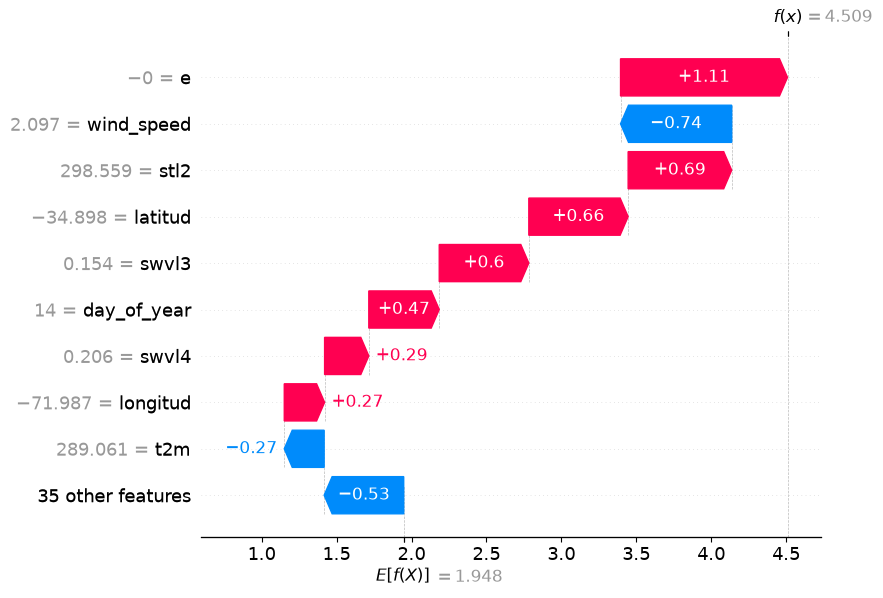

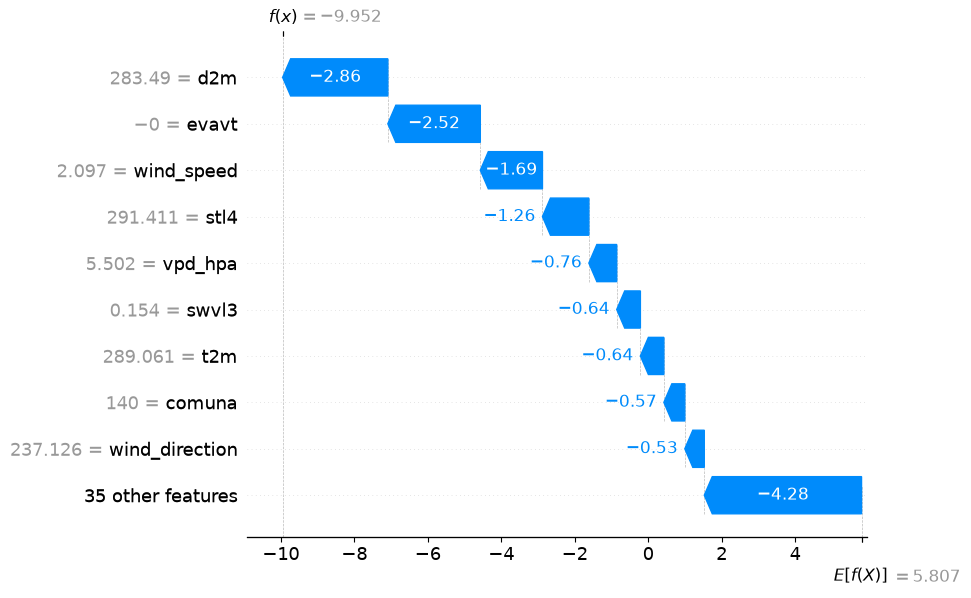

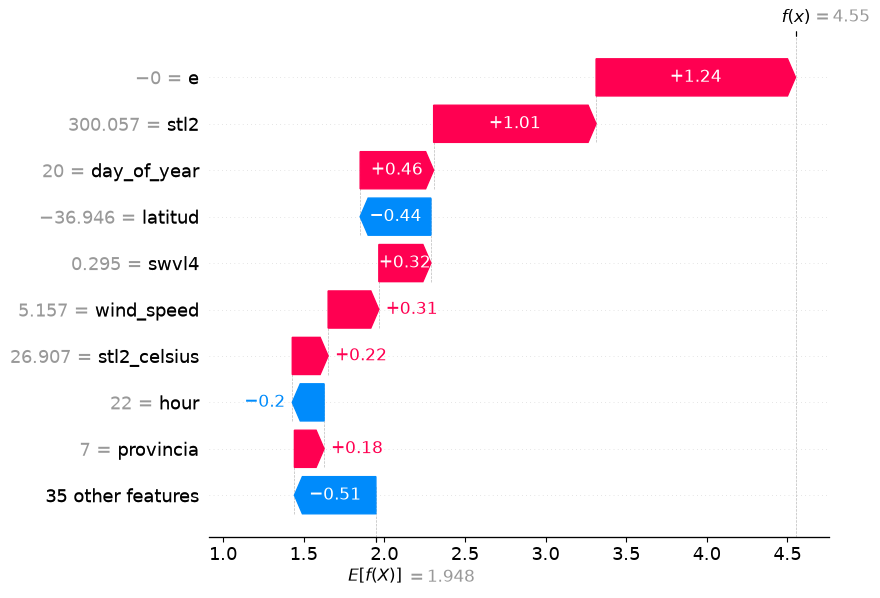

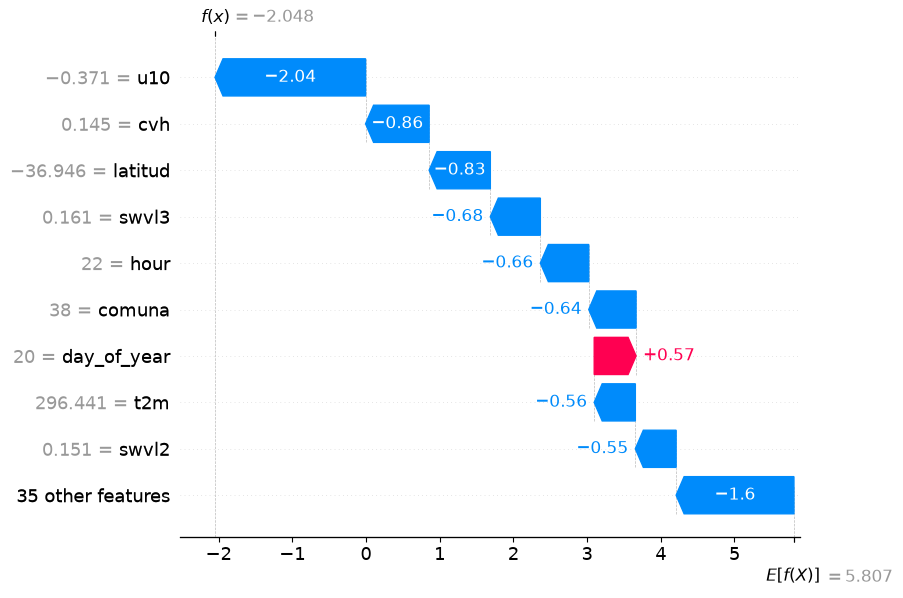

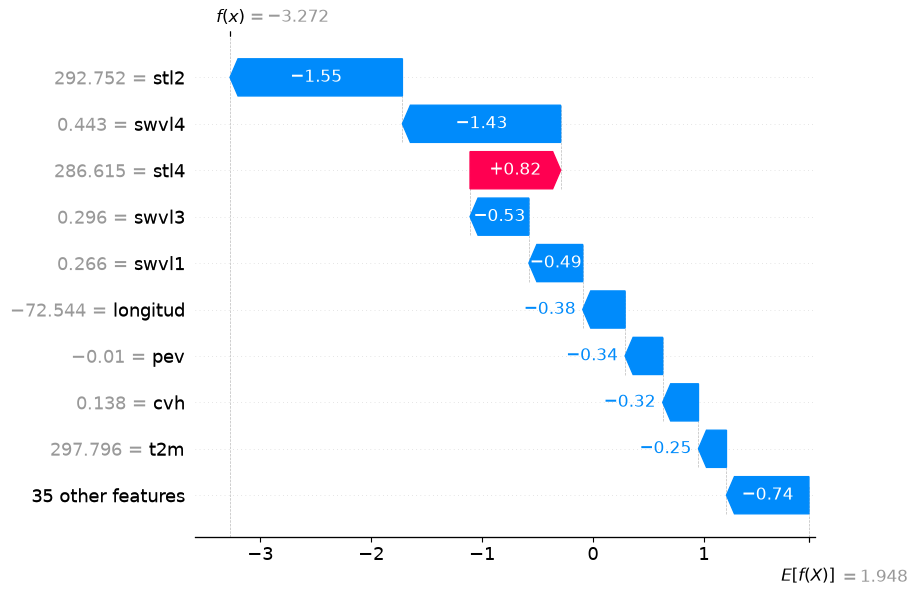

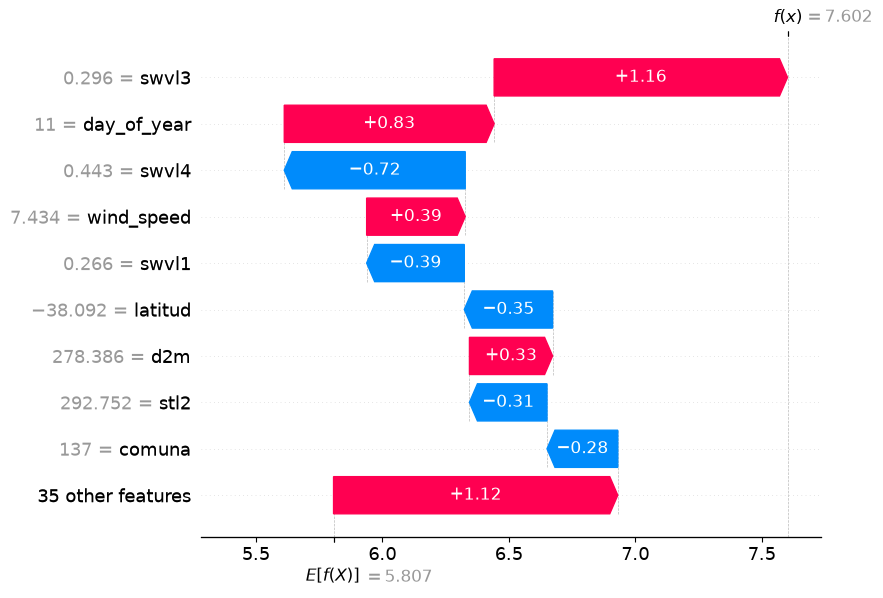

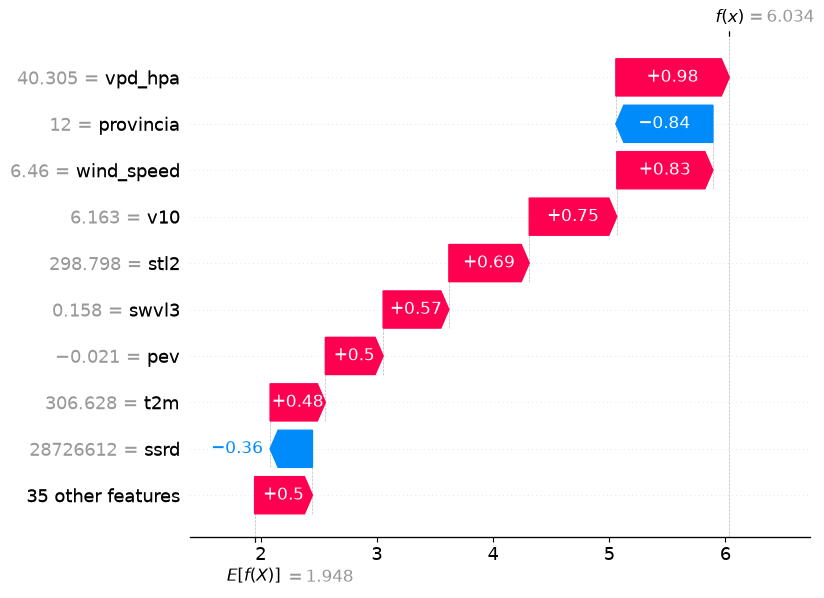

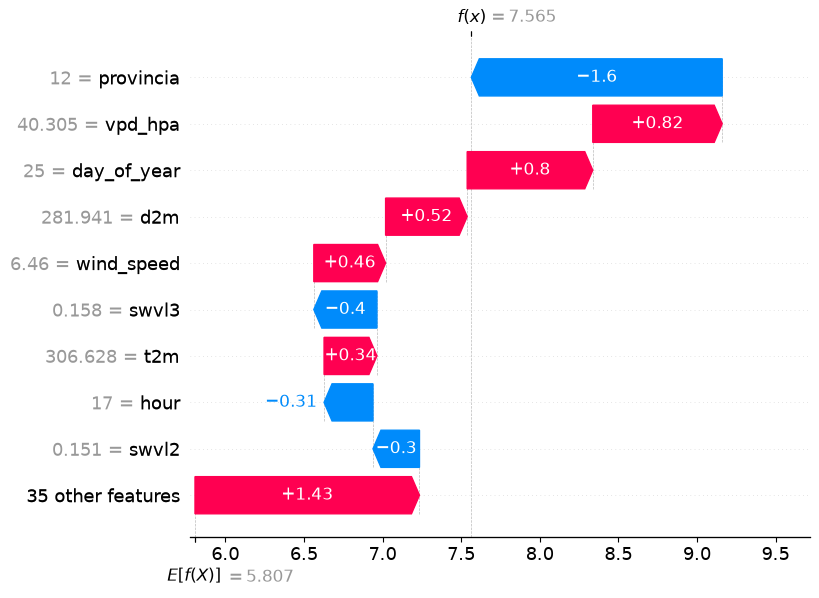

In [9]:
for title, idx in instances.items():
    row = df.loc[idx]
    iloc_idx = iloc_mapping[idx]

    # L1 Waterfall
    shap.plots.waterfall(sv_l1[iloc_idx], max_display=10, show=False)
    b64_w_l1 = image_to_base64(plt.gcf())

    # L2 Waterfall
    shap.plots.waterfall(sv_l2[iloc_idx], max_display=10, show=False)
    b64_w_l2 = image_to_base64(plt.gcf())

    html_content += f"""
    <div class="instance-box">
        <h3>{title}</h3>
        <p>
            <strong>Date (UTC):</strong> {row['fecha_hora_inicio_utc']} |
            <strong>Area:</strong> {row['superficie_quemada_total_ha']:.1f} ha |
            <strong>Max FRP:</strong> {row.get('modis_frp_max_mw', 'N/A')} MW
        </p>
        <div class="flex">
            <div class="flex-child">
                <h4>L1 Model Perspective (Area)</h4>
                <img src="data:image/png;base64,{b64_w_l1}" />
            </div>
            <div class="flex-child">
                <h4>L2 Model Perspective (Intensity)</h4>
                <img src="data:image/png;base64,{b64_w_l2}" />
            </div>
        </div>
    </div>
    """

## 9. Escritura del reporte

In [10]:
html_content += """
    </div>
</body>
</html>
"""

HTML_OUT.write_text(html_content, encoding="utf-8")
print(f"\n✅ Report generated successfully at {HTML_OUT}")


✅ Report generated successfully at /home/imorales/Desktop/XAI/XAI-project/eda/L1_vs_L2_Experiment_Report.html
